Build a very simple Binary Classifire NN

#### work process example

In [1]:
from nn import MLP

In [2]:
# four possible inputs 
xs = [
    [2.0, 3.0, -2.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

In [3]:
model = MLP(3, [4, 4, 1])

In [12]:
for i in range(10):
    ypred = [model(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    model.zero_grad()
    loss.backward()
    
    for p in model.parameters():
        p.data -= 0.1 * p.grad

    print(f"{i} | {loss.data}")

0 | 0.003871659155000086
1 | 0.0038049235225032065
2 | 0.0037403920727330266
3 | 0.003677958327711643
4 | 0.003617522530154683
5 | 0.003558991122722857
6 | 0.003502276274882781
7 | 0.0034472954523804035
8 | 0.0033939710249197693
9 | 0.0033422299081535493


In [13]:
ypred

[Value(data=0.9798620176095343, grad=-0.04027596478093143),
 Value(data=-0.9883308966181947, grad=0.023338206763610536),
 Value(data=-0.9636405931030144, grad=0.07271881379397116),
 Value(data=0.9615485093948359, grad=-0.07690298121032813)]

In [14]:
model([2.5, -1.0, -0.5])

Value(data=-0.9810814943134093, grad=0.0)

#### binary classifire example

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from nn import MLP

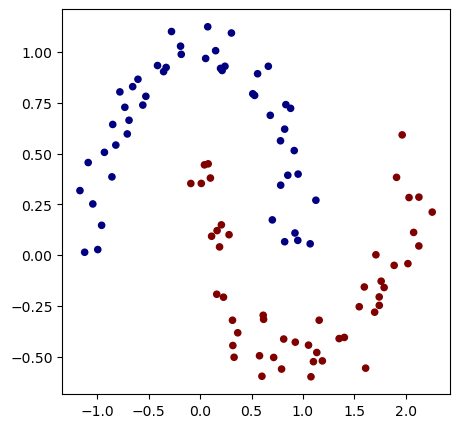

In [50]:
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1  # tanh() works better if y in (-1, 1) then in (0, 1)
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [53]:
# initialize model with 2 input parameters (X coordinates)
model = MLP(2, [16, 16, 1]) 
print("number of parameters:", len(model.parameters()))

number of parameters: 337


In [22]:
def loss():
    scores = list(map(model, X))

    total_loss = sum((yout - ygt)**2 for ygt, yout in zip(y, scores))

    accuracy = [(ygt > 0) == (yout.data > 0) for ygt, yout in zip(y, scores)]

    return total_loss, sum(accuracy) / len(accuracy)
    

In [54]:
total_loss, acc = loss()
print(total_loss, acc)

Value(data=198.04969836060047, grad=0.0) 0.41


In [55]:
# learning
for i in range(35):

    # forward
    total_loss, acc = loss()

    # backward
    model.zero_grad()
    total_loss.backward()

    learning_rate = 0.005
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    if i % 1 == 0:
        print(f"step {i} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 198.04969836060047, accuracy 41.0%
step 1 loss 113.96984530705959, accuracy 71.0%
step 2 loss 101.74005726498696, accuracy 73.0%
step 3 loss 92.62122537642881, accuracy 74.0%
step 4 loss 83.96608215320448, accuracy 76.0%
step 5 loss 69.82237118809378, accuracy 80.0%
step 6 loss 39.21661284389253, accuracy 89.0%
step 7 loss 44.49494670028779, accuracy 85.0%
step 8 loss 91.415597294954, accuracy 75.0%
step 9 loss 64.98383989698618, accuracy 81.0%
step 10 loss 47.43397838210592, accuracy 85.0%
step 11 loss 26.15043958677494, accuracy 91.0%
step 12 loss 21.058306502689366, accuracy 92.0%
step 13 loss 44.0273316832636, accuracy 87.0%
step 14 loss 34.67221547841652, accuracy 89.0%
step 15 loss 74.9013146942967, accuracy 80.0%
step 16 loss 48.36273513869897, accuracy 85.0%
step 17 loss 27.64902723382787, accuracy 92.0%
step 18 loss 10.577743738352135, accuracy 97.0%
step 19 loss 7.898028807178569, accuracy 99.0%
step 20 loss 9.972001937913987, accuracy 96.0%
step 21 loss 31.634865

(-1.5989993484784923, 1.9010006515215077)

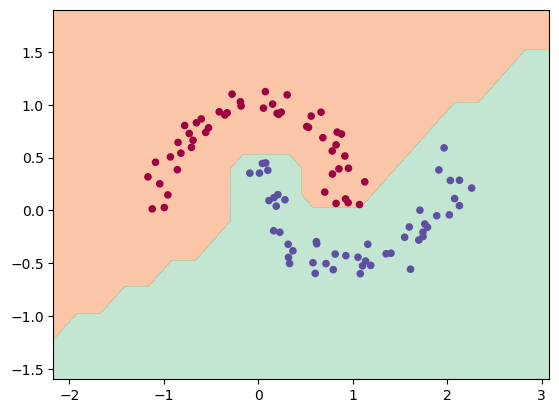

In [59]:
grid_step = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step), 
                     np.arange(y_min, y_max, grid_step))

Xmesh = np.c_[xx.ravel(), yy.ravel()]

scores = list(map(model, Xmesh)) # get a prediction for every dot of the grid
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())